<a href="https://colab.research.google.com/github/jivaniaadit/factor_xa_cheminformatics/blob/main/notebooks/week1day4Morgan_Fingerprints_and_Tanimoto_Similarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rdkit -q
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Draw
import pandas as pd
import numpy as np

In [ ]:
mol = Chem.MolFromSmiles('CC(=O)Oc1ccccc1C(=O)O')
fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
print(fp)
print(f"Number of bits set: {fp.GetNumOnBits()}")

Number of bits set: 24


[16:54:50] DEPRECATION WARNING: please use MorganGenerator


In [ ]:
drugs = {
    'Aspirin': 'CC(=O)Oc1ccccc1C(=O)O',
    'Ibuprofen': 'CC(C)Cc1ccc(C(C)C(=O)O)cc1',
    'Acetaminophen': 'CC(=O)Nc1ccc(O)cc1',
    'Caffeine': 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',
    'Penicillin G': 'CC1(C)SC2C(NC(=O)Cc3ccccc3)C(=O)N2C1C(=O)O',
    'Diazepam': 'CN1C(=O)CN=C(c2ccccc2)c2cc(Cl)ccc21',
    'Propranolol': 'CC(C)NCC(O)COc1cccc2ccccc12',
    'Fluoxetine': 'CNCCC(Oc1ccc(C(F)(F)F)cc1)c1ccccc1',
    'Atorvastatin': 'CC(C)c1c(C(=O)Nc2ccccc2)c(-c2ccccc2)c(-c2ccc(F)cc2)n1CC[C@@H](O)C[C@@H](O)CC(=O)O',
    'Metformin': 'CN(C)C(=N)NC(=N)N',
}

aspirin = Chem.MolFromSmiles(drugs['Aspirin'])
ibuprofen = Chem.MolFromSmiles(drugs['Ibuprofen'])

fp1 = AllChem.GetMorganFingerprintAsBitVect(aspirin, 2, 2048)
fp2 = AllChem.GetMorganFingerprintAsBitVect(ibuprofen, 2, 2048)

similarity = DataStructs.TanimotoSimilarity(fp1, fp2)
print(f"Aspirin vs Ibuprofen: {similarity:.3f}")

Aspirin vs Ibuprofen: 0.195


[16:57:28] DEPRECATION WARNING: please use MorganGenerator
[16:57:28] DEPRECATION WARNING: please use MorganGenerator


In [ ]:
generator = AllChem.GetMorganGenerator(radius = 2, fpSize = 2048)

fingerprints = {}

for name, smiles in drugs.items():
  mol = Chem.MolFromSmiles(smiles)
  if mol is None:
    continue

  fp = generator.GetFingerprint(mol)
  fingerprints[name] = fp
drug_names = list(fingerprints.keys())

matrix = []

for name_A in drug_names:
  row_scores = []
  fp_A = fingerprints[name_A]
  for name_B in drug_names:
    fp_B = fingerprints[name_B]
    score = DataStructs.TanimotoSimilarity(fp_A, fp_B)
    row_scores.append(score)
  matrix.append(row_scores)

df_similarity = pd.DataFrame(matrix, index = drug_names, columns = drug_names)
df_similarity

,Aspirin,Ibuprofen,Acetaminophen,Caffeine,Penicillin G,Diazepam,Propranolol,Fluoxetine,Atorvastatin,Metformin
Aspirin,1.000000,0.195122,0.222222,0.088889,0.175439,0.148148,0.204082,0.153846,0.157143,0.051282
Ibuprofen,0.195122,1.000000,0.184211,0.086957,0.172414,0.105263,0.153846,0.150943,0.154930,0.050000
Acetaminophen,0.222222,0.184211,1.000000,0.097561,0.145455,0.115385,0.122449,0.098039,0.166667,0.088235
Caffeine,0.088889,0.086957,0.097561,1.000000,0.096774,0.145455,0.071429,0.051724,0.078947,0.024390
Penicillin G,0.175439,0.172414,0.145455,0.096774,1.000000,0.157143,0.130435,0.128571,0.149425,0.052632
Diazepam,0.148148,0.105263,0.115385,0.145455,0.157143,1.000000,0.089552,0.104478,0.158537,0.037736
Propranolol,0.204082,0.153846,0.122449,0.071429,0.130435,0.089552,1.000000,0.183333,0.194805,0.083333
Fluoxetine,0.153846,0.150943,0.098039,0.051724,0.128571,0.104478,0.183333,1.000000,0.162500,0.039216
Atorvastatin,0.157143,0.154930,0.166667,0.078947,0.149425,0.158537,0.194805,0.162500,1.000000,0.042254
Metformin,0.051282,0.050000,0.088235,0.024390,0.052632,0.037736,0.083333,0.039216,0.042254,1.000000


In [ ]:
#find the 3 most similar drugs in the set for a drug (diazepam)

def nearest_neighbours(query_smiles, fingerprints):
  query_mol = Chem.MolFromSmiles(query_smiles)
  query_fp = generator.GetFingerprint(query_mol)

  scores = []
  for name, fp in fingerprints.items():
    sim = DataStructs.TanimotoSimilarity(query_fp, fp)
    scores.append((name, sim))

  scores.sort(key = lambda x:x[1], reverse = True)

  filtered_scores = []
  for item in scores:
    name = item[0]
    sim_value = item[1]
    if sim_value < 0.999:
      filtered_scores.append(item)

  return filtered_scores[:3]

nearest_neighbours(drugs['Diazepam'], fingerprints)

[('Atorvastatin', 0.15853658536585366),
 ('Penicillin G', 0.15714285714285714),
 ('Aspirin', 0.14814814814814814)]

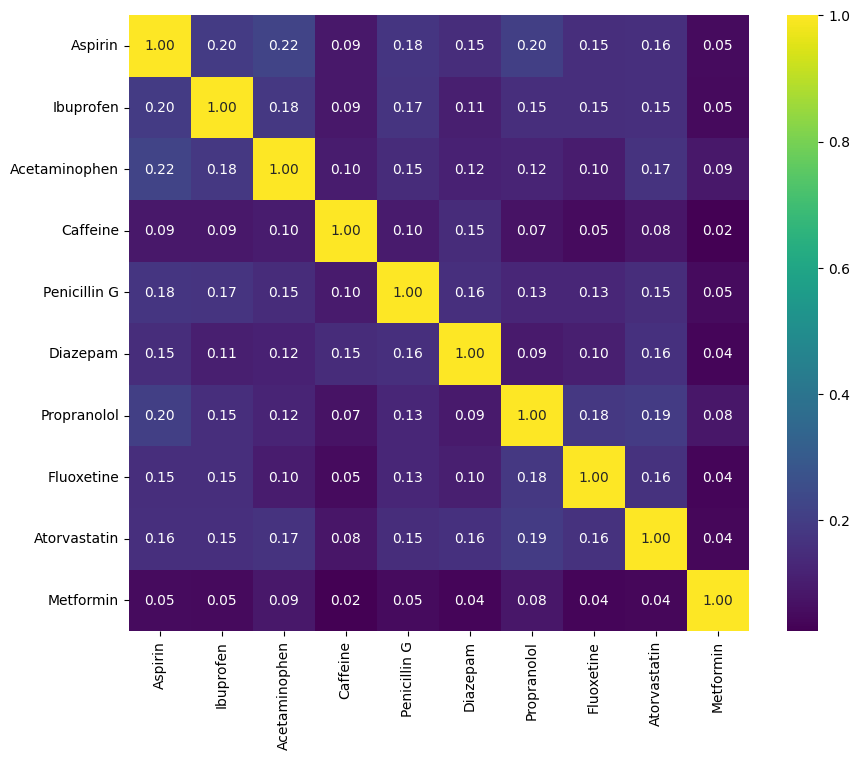

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df_similarity, annot=True, cmap='viridis', fmt='.2f')
plt.show()